# 并行中断

In [1]:
from typing import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Command, interrupt
from rich import print


# 声明状态
class State(TypedDict):
    username: str
    age: str


# 声明节点
def ask_name(state: State) -> dict:
    print("=========== 执行 ask_name 节点===========")
    username = interrupt("请输入你的名字")
    return {
        "username": username,
    }


def ask_age(state: State) -> dict:
    print("=========== 执行 ask_age 节点===========")
    age = interrupt("请输入你的年龄")
    return {
        "age": age,
    }


# 构建图结构
builder = StateGraph(state_schema=State)
builder.add_node("ask_name", ask_name)
builder.add_node("ask_age", ask_age)
builder.add_edge(START, "ask_name")
builder.add_edge(START, "ask_age")
builder.add_edge("ask_name", END)
builder.add_edge("ask_age", END)

# 使用中断必须设置检查点
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer)

# 执行
config = {"configurable": {"thread_id": "123"}}
res = graph.invoke({}, config=config)
print(res)

=========== 执行 ask_age 节点===========

=========== 执行 ask_name 节点===========

{
    '__interrupt__': [
        Interrupt(value='请输入你的年龄', id='ea08d9b12df071534e66daac7ac8d119'),
        Interrupt(value='请输入你的名字', id='0ddec9001265de9fd91caa165fdcbef4')
    ]
}

In [11]:
# 恢复执行
resume_map = {}  # { id : msg }
for i in res['__interrupt__']:
    ask_msg = input(f"{i.value}")
    resume_map[i.id] = ask_msg
resume_res = graph.invoke(Command(resume=resume_map), config=config)
print(resume_res)

=========== 执行 ask_age 节点===========

=========== 执行 ask_name 节点===========

{'username': 'aihaipeng', 'age': '26'}

In [12]:
print(list(graph.get_state_history(config=config)))

[
    StateSnapshot(
        values={'username': 'aihaipeng', 'age': '26'},
        next=(),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1af9dd-7253-695f-8001-db9639631a73'
            }
        },
        metadata={'source': 'loop', 'step': 1, 'parents': {}},
        created_at='2026-09-13T18:06:27.946316+00:00',
        parent_config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1af9dc-eb80-6be2-8000-5820a5f9e84b'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={},
        next=('ask_name', 'ask_age'),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1af9dc-eb80-6be2-8000-5820a5f9e84b'
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {}},
        created_at='2026-09-13T18:06:13.809041+00:00',
        parent_config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1af9dc-eb7f-63ce-bfff-cdba86f32a0a'
            }
        },
        tasks=(
            PregelTask(
                id='eebdee9e-8c04-8531-98b1-dd9440b50fcb',
                name='ask_name',
                path=('__pregel_pull', 'ask_name'),
                error=None,
                interrupts=(Interrupt(value='请输入你的名字', id='c79d0a99dff3009e3a6ef3f4dbbeb1ef'),),
                state=None,
                result={'username': 'aihaipeng'}
            ),
            PregelTask(
                id='b68f1b18-e49f-1a09-ddfd-da34abef01ca',
                name='ask_age',
                path=('__pregel_pull', 'ask_age'),
                error=None,
                interrupts=(Interrupt(value='请输入你的年龄', id='1bd4bbb5be2955a116912c5752c67ed9'),),
                state=None,
                result={'age': '26'}
            )
        ),
        interrupts=(
            Interrupt(value='请输入你的名字', id='c79d0a99dff3009e3a6ef3f4dbbeb1ef'),
            Interrupt(value='请输入你的年龄', id='1bd4bbb5be2955a116912c5752c67ed9')
        )
    ),
    StateSnapshot(
        values={},
        next=('__start__',),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1af9dc-eb7f-63ce-bfff-cdba86f32a0a'
            }
        },
        metadata={'source': 'input', 'step': -1, 'parents': {}},
        created_at='2026-09-13T18:06:13.808426+00:00',
        parent_config=None,
        tasks=(
            PregelTask(
                id='0948f8c7-563d-b556-1ecb-2b50e16f399d',
                name='__start__',
                path=('__pregel_pull', '__start__'),
                error=None,
                interrupts=(),
                state=None,
                result={}
            ),
        ),
        interrupts=()
    )
]

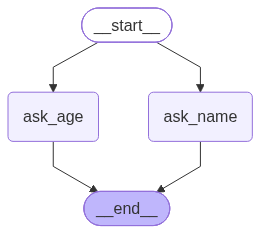

None

In [14]:
from IPython.display import display

print(display(graph))